In [13]:
import os, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.fft import fft, fftfreq, fftshift

In [14]:
files = sorted([int(path[-1]) for path in os.listdir('.') if 'test' in path])
files

[1, 2, 3, 4, 5, 6, 7]

In [15]:
def compareAxis(data, yTicks=None, normalize=False):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 5*numRows))

    for i, (key, values) in enumerate(data.items()):
        if normalize: 
            values = values - np.mean(values[:50])

        plt.subplot(numRows, numCols, i+1)
        plt.plot(values)
        plt.title(key)
        plt.grid(True)

        if yTicks is not None: 
            plt.yticks(yTicks)

    plt.tight_layout()
    plt.show()

# COMPARANDO DADOS - Kernel

In [16]:
def convertKernel(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df

In [17]:
tests = {}

for id in files:
    path_x = f'test{id}/rolling_x/target/data.csv'
    path_z = f'test{id}/rolling_z/target/data.csv'

    tests[id] = {
        'x': convertKernel(pd.read_csv(path_x)) if os.path.exists(path_x) else None,
        'z': convertKernel(pd.read_csv(path_z)) if os.path.exists(path_z) else None
    }

tests[1]['x']

,yaw,roll,ay,time,wx,tmp,pitch,az,ax,wy,wz,e
0,0.198,-3.404,0.069990,4.768372e-07,0.31519,23.6,0.152,9.802531,0.580838,0.49363,-0.01744,0.000
1,0.202,-3.408,0.010022,8.113146e-02,-0.11155,23.5,0.155,9.701317,0.581829,-0.18269,0.05879,0.000
2,0.204,-3.411,-0.003727,1.782725e-01,0.35175,23.5,0.157,9.785066,0.579151,0.08882,-0.24270,0.000
3,0.204,-3.416,-0.003609,2.746692e-01,0.00503,23.6,0.159,9.761255,0.569345,0.15458,-0.32747,0.000
4,0.205,-3.416,0.031352,3.802705e-01,0.18911,23.6,0.161,9.775592,0.595038,-0.44715,-0.14957,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...
2290,2.533,-3.367,-0.080787,2.289809e+02,0.43945,39.3,-0.438,9.779770,0.567530,0.01173,0.15772,0.216
2291,2.534,-3.365,-0.099410,2.290757e+02,0.00092,39.4,-0.438,9.766923,0.548780,0.13711,0.06991,0.216
2292,2.534,-3.364,-0.121730,2.291833e+02,0.12125,39.6,-0.441,9.758588,0.600383,-0.14945,-0.01280,0.216
2293,2.536,-3.364,-0.039354,2.292804e+02,0.08406,39.4,-0.443,9.760216,0.582417,0.39784,0.08026,0.216


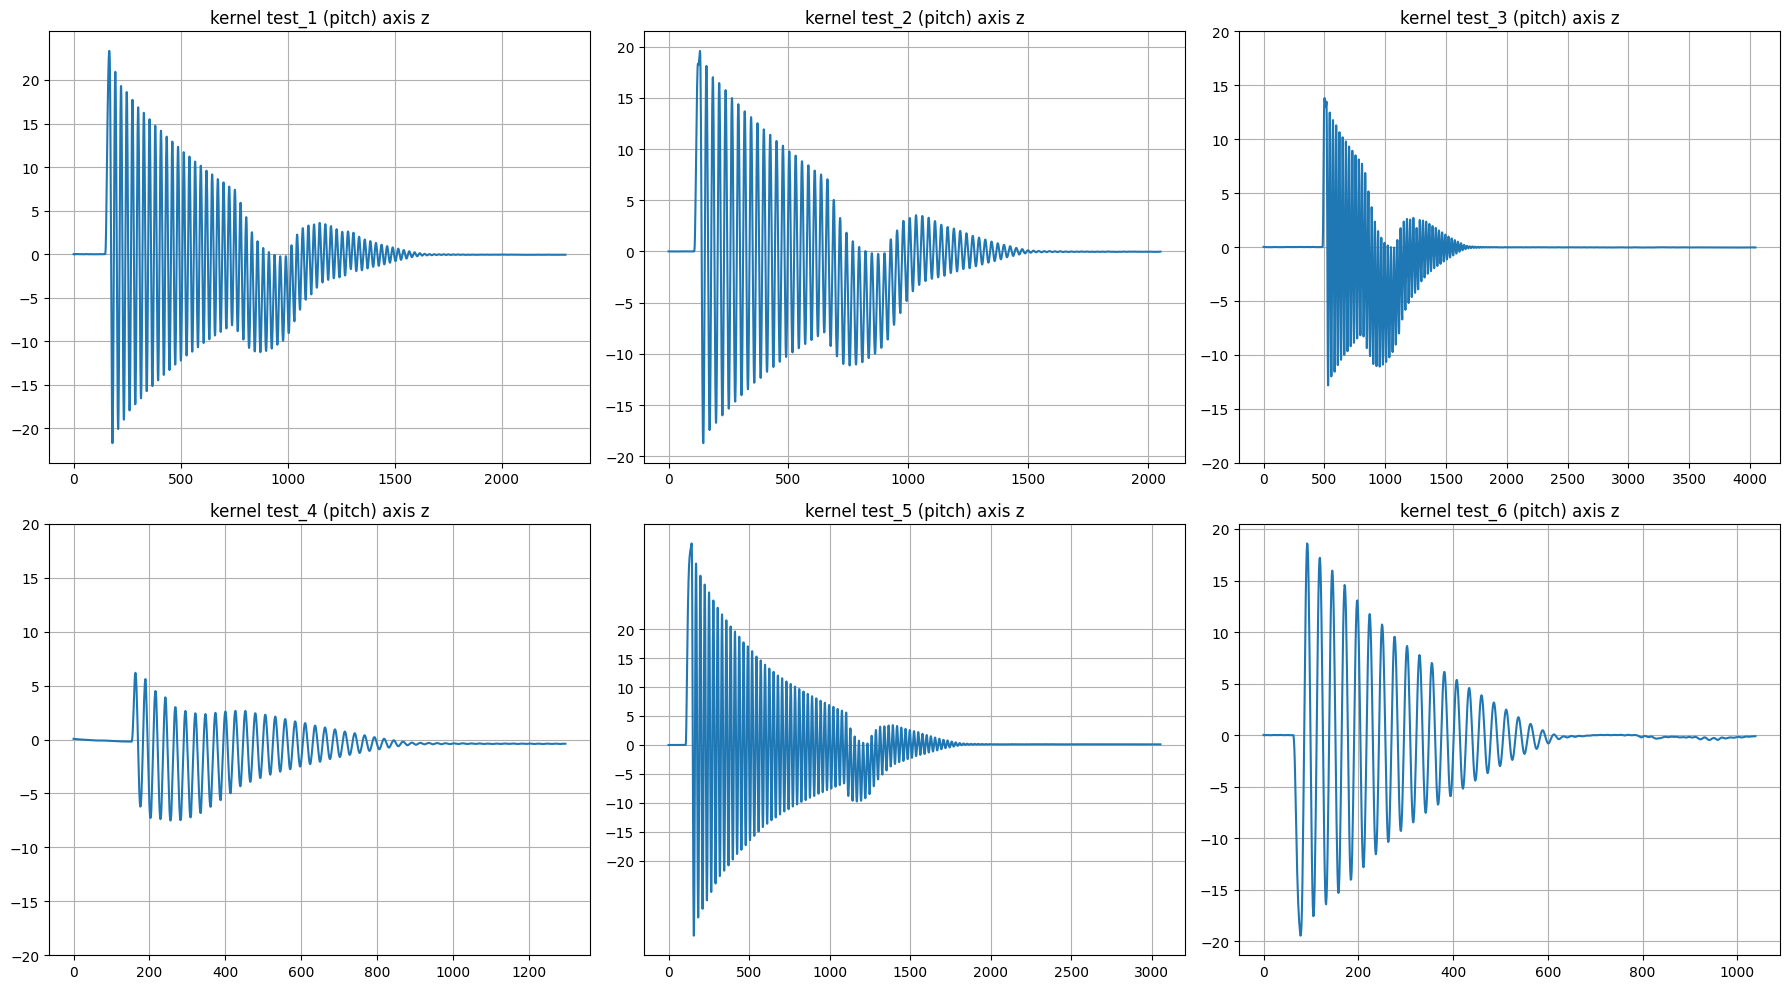

In [18]:
axis = 'z'
var  = 'pitch'
graphs = {}

for id, data in tests.items():
    if data[axis] is None:
        continue

    values = data[axis][var].to_numpy()
    graphs[f'kernel test_{id} ({var}) axis {axis}'] = values

compareAxis(graphs, yTicks=np.arange(-20, 21, 5), normalize=True)

# COMPARANDO FREQUÊNCIAS - Kernel

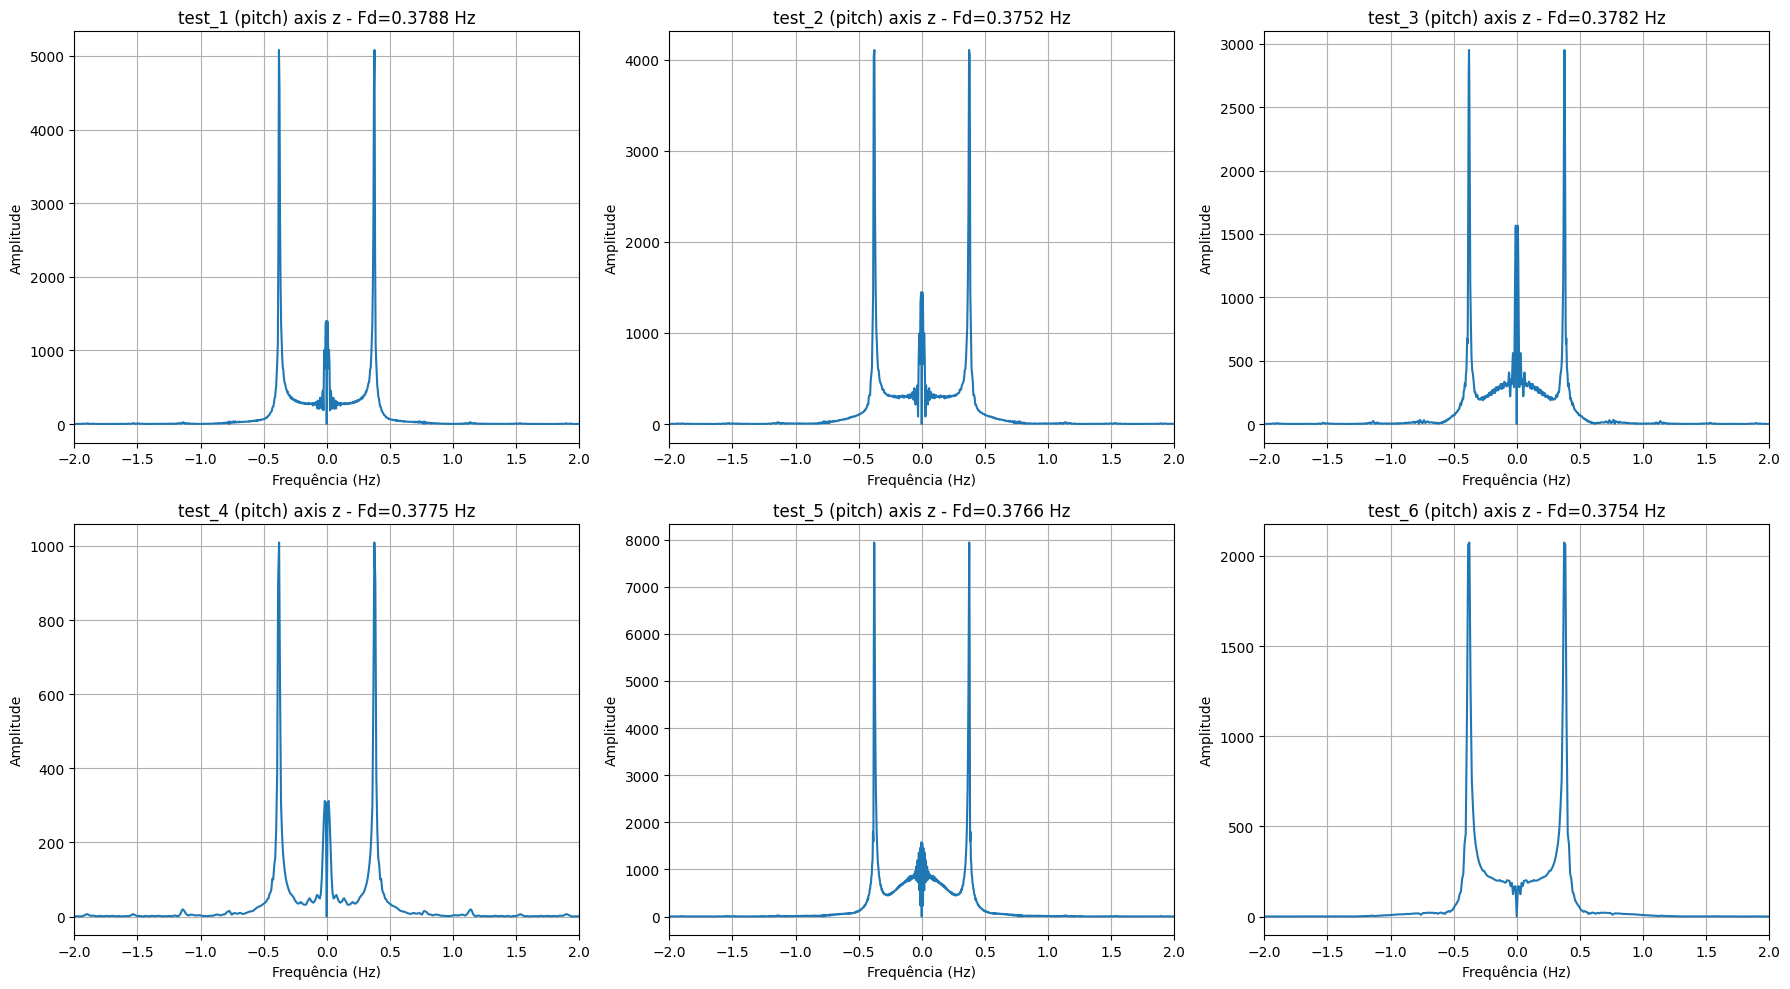

In [19]:
def getPeakFreq(values, fs=10, title='Espectro de Frequência', plot=False):
    normalized = values - np.mean(values)
    N  = len(normalized)
    
    yf = fft(normalized)
    xf = fftfreq(N, 1 / fs)
    
    yf_shifted = fftshift(yf)
    xf_shifted = fftshift(xf)
    amplitudes = np.abs(yf_shifted)
    peak_index = np.argmax(amplitudes)
    dominant_freq = abs(xf_shifted[peak_index]) 
    
    if not plot:
        return dominant_freq
    
    plt.plot(xf_shifted, amplitudes)
    plt.title(f"{title} - Fd={dominant_freq:.4f} Hz")
    plt.xlabel("Frequência (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.xlim(-2, 2)
    return dominant_freq

def compareFrequencies(data):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 5*numRows))

    for i, (key, values) in enumerate(data.items()):
        plt.subplot(numRows, numCols, i+1)
        getPeakFreq(values, fs=10, plot=True, title=key) # 10 hz

    plt.tight_layout()
    plt.show()


axis = 'z'
var  = 'pitch'
graphs = {}

for id, data in tests.items():
    if data[axis] is None:
        continue

    values = data[axis][var].to_numpy()
    graphs[f'test_{id} ({var}) axis {axis}'] = values

compareFrequencies(graphs)

# TESTE DE FUSAO

Text(0.5, 1.0, 'roll calculated')

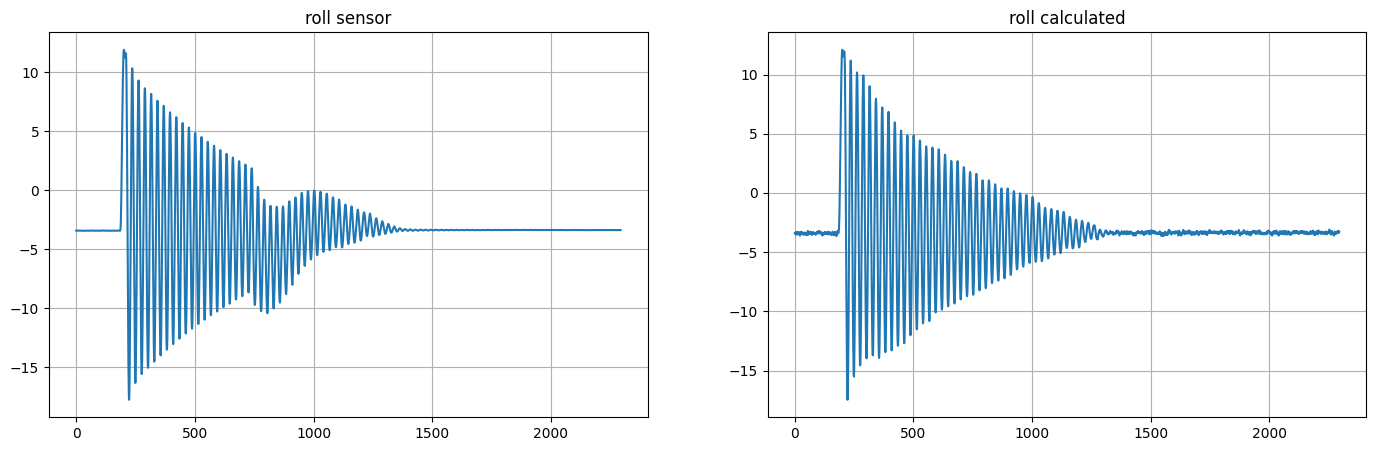

In [20]:
import math

class OrientationParser:
    """
    Filtro de Madgwick para fusão IMU (gyro + accel).
    Portável direto para C++ — sem dependências externas, só math.
    
    Parâmetros:
        beta          — ganho de correção do acelerômetro (0.005–0.05)
        accel_min     — norma mínima do accel para aceitar correção (evita div/0)
        accel_max     — norma máxima do accel (rejeita amostras em vibração intensa > 2g)
        dt_min/dt_max — clamp de dt em segundos
    """
    def __init__(self, beta=0.01, accel_min=0.5, accel_max=19.6, dt_min=1e-6, dt_max=0.15):
        self.q0, self.q1, self.q2, self.q3 = 1.0, 0.0, 0.0, 0.0
        self.beta      = beta
        self.accel_min = accel_min
        self.accel_max = accel_max
        self.dt_min    = dt_min
        self.dt_max    = dt_max
        self.yaw       = 0.0
        self.pitch     = 0.0
        self.roll      = 0.0
        self._initialized = False

    def start(self, ax, ay, az):
        norm = math.sqrt(ax*ax + ay*ay + az*az)
        if norm < self.accel_min:
            return  # leitura inválida, fica em identidade
        ax /= norm; ay /= norm; az /= norm

        if az >= 0.0:
            denom = math.sqrt(2.0 * (az + 1.0))
            if denom < 1e-10:
                return
            self.q0 =  denom / 2.0
            self.q1 =  ay / denom  # convencione: -ay se seu eixo for invertido
            self.q2 = -ax / denom
            self.q3 =  0.0
        else:
            denom = math.sqrt(2.0 * (1.0 - az))
            if denom < 1e-10:
                return
            self.q0 =  ay / denom
            self.q1 =  denom / 2.0
            self.q2 =  0.0
            self.q3 =  ax / denom

        rn = self._recipnorm4(self.q0, self.q1, self.q2, self.q3)
        if rn is not None:
            self.q0 *= rn; self.q1 *= rn
            self.q2 *= rn; self.q3 *= rn
        self._initialized = True


    def update(self, gx, gy, gz, ax, ay, az, dt):
        dt = max(self.dt_min, min(dt, self.dt_max))
        q0, q1, q2, q3 = self.q0, self.q1, self.q2, self.q3

        # 2. Derivada do quaternion pelo giroscópio
        qDot1 = 0.5 * (-q1*gx - q2*gy - q3*gz)
        qDot2 = 0.5 * ( q0*gx + q2*gz - q3*gy)
        qDot3 = 0.5 * ( q0*gy - q1*gz + q3*gx)
        qDot4 = 0.5 * ( q0*gz + q1*gy - q2*gx)

        # 3. Correção pelo acelerômetro (Madgwick gradient descent)
        accel_norm = math.sqrt(ax*ax + ay*ay + az*az)
        
        # Aceita apenas se a norma está dentro da janela "gravidade dominante"
        # accel_max rejeita amostras em vibração/movimento brusco (> 2g)
        if self.accel_min < accel_norm < self.accel_max:
            inv = 1.0 / accel_norm
            ax *= inv; ay *= inv; az *= inv

            q0q0 = q0*q0; q1q1 = q1*q1
            q2q2 = q2*q2; q3q3 = q3*q3
            _2q0 = 2.0*q0; _2q1 = 2.0*q1
            _2q2 = 2.0*q2; _2q3 = 2.0*q3
            _4q0 = 4.0*q0; _4q1 = 4.0*q1; _4q2 = 4.0*q2
            _8q1 = 8.0*q1; _8q2 = 8.0*q2

            s0 = _4q0*q2q2 + _2q2*ax + _4q0*q1q1 - _2q1*ay
            s1 = (_4q1*q3q3 - _2q3*ax
                  + 4.0*q0q0*q1 - _2q0*ay
                  - _4q1 + _8q1*q1q1 + _8q1*q2q2 + _4q1*az)
            s2 = (4.0*q0q0*q2 + _2q0*ax
                  + _4q2*q3q3 - _2q3*ay
                  - _4q2 + _8q2*q1q1 + _8q2*q2q2 + _4q2*az)
            s3 = 4.0*q1q1*q3 - _2q1*ax + 4.0*q2q2*q3 - _2q2*ay

            rn = self._recipnorm4(s0, s1, s2, s3)
            if rn is not None:
                qDot1 -= self.beta * s0 * rn
                qDot2 -= self.beta * s1 * rn
                qDot3 -= self.beta * s2 * rn
                qDot4 -= self.beta * s3 * rn

        # 4. Integração de Euler de 1ª ordem
        q0 += qDot1 * dt
        q1 += qDot2 * dt
        q2 += qDot3 * dt
        q3 += qDot4 * dt

        # 5. Renormaliza — se degenerar, reinicia para identidade
        rn = self._recipnorm4(q0, q1, q2, q3)
        if rn is None:
            self.q0, self.q1, self.q2, self.q3 = 1.0, 0.0, 0.0, 0.0
            return
        self.q0 = q0 * rn
        self.q1 = q1 * rn
        self.q2 = q2 * rn
        self.q3 = q3 * rn

        self._compute_euler()

    # ------------------------------------------------------------------
    # Extração de ângulos de Euler (convenção ZYX / NED)
    # Roll (X) → Pitch (Y) → Yaw (Z)
    # ------------------------------------------------------------------
    def _compute_euler(self):
        q0, q1, q2, q3 = self.q0, self.q1, self.q2, self.q3

        # Yaw — corrigido: denominador usa q1²+q2², não q1²+q3²
        self.yaw = math.atan2(
            2.0*(q1*q2 - q0*q3),
            1.0 - 2.0*(q1*q1 + q2*q2)
        ) * (180.0 / math.pi)

        # Pitch — clamp explícito antes do asin (evita NaN por float noise)
        sinp = 2.0*(q2*q3 + q0*q1)
        self.pitch = math.asin(max(-1.0, min(1.0, sinp))) * (180.0 / math.pi)

        # Roll — negado para convenção NED
        self.roll = -math.atan2(
            2.0*(q1*q3 - q0*q2),
            1.0 - 2.0*(q1*q1 + q2*q2)
        ) * (180.0 / math.pi)

    # ------------------------------------------------------------------
    # Auxiliar — retorna 1/‖v‖ ou None se ‖v‖ < 1e-10 (portável para C++)
    # ------------------------------------------------------------------
    @staticmethod
    def _recipnorm4(a, b, c, d):
        n = a*a + b*b + c*c + d*d
        if n < 1e-10:
            return None
        return 1.0 / math.sqrt(n)



df  = tests[1]['x']
var = 'roll'

parser = OrientationParser()
parser.start(df.iloc[0].ax, df.iloc[0].ay, df.iloc[0].az)

prev_time = df.time.values[0]
values    = list()

for _, row in df.iterrows():
    dt = (row.time - prev_time)
    prev_time = row.time
    wx, wy, wz = (np.pi/180.0*row.wx), (np.pi/180.0*row.wy), (np.pi/180.0*row.wz) 
    ax, ay, az = row.ax, row.ay, row.az
    parser.update(wx, wy, wz, ax, ay, az, dt)
    values.append([parser.pitch, parser.roll, parser.yaw])

df['calc_pitch'] = [pitch for (pitch, roll, yaw) in values]
df['calc_roll']  = [roll  for (pitch, roll, yaw) in values]
df['calc_yaw']   = [yaw   for (pitch, roll, yaw) in values]

plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
df[var].plot(); plt.grid()
plt.title(f'{var} sensor')

plt.subplot(1, 2, 2)
df[f'calc_{var}'].plot(); plt.grid()
plt.title(f'{var} calculated')

# COMPARANDO DADOS - Kongsberg

In [21]:
def convertKongsberg(df):
    for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
        df.loc[:, col] = df[col] * 180.00/np.pi

    return df

In [22]:
tests = {}

for id in files:
    path_x = f'test{id}/rolling_x/reference/data.csv'
    path_z = f'test{id}/rolling_z/reference/data.csv'

    tests[id] = {
        'x': convertKongsberg(pd.read_csv(path_x)) if os.path.exists(path_x) else None,
        'z': convertKongsberg(pd.read_csv(path_z)) if os.path.exists(path_z) else None
    }

tests[1]['x']

,q0,q1,roll,yaw,ay,time,wx,sample_time,pitch,az,q2,ax,q3,wy,wz,la_pos_mon_d
0,1.0000,0.000103,0.011579,0.003933,9.785,4.768372e-07,0.027662,205000000.0,-0.010926,-0.1967,-0.000097,0.1261,0.000035,0.002956,0.023445,0.000
1,1.0000,0.000118,0.013327,0.005901,9.783,8.113146e-02,0.021681,305000000.0,-0.012456,-0.1963,-0.000110,0.1255,0.000053,-0.018094,0.015762,0.000
2,1.0000,0.000134,0.015298,0.009397,9.784,1.782725e-01,0.030092,405000000.0,-0.013109,-0.1968,-0.000115,0.1253,0.000084,-0.010880,0.031816,0.000
3,1.0000,0.000159,0.018134,0.013109,9.784,2.746692e-01,0.032584,505000000.0,-0.014421,-0.1965,-0.000126,0.1246,0.000116,-0.012542,0.039385,0.000
4,1.0000,0.000181,0.020541,0.016828,9.784,3.802705e-01,0.026144,605000000.0,-0.015298,-0.1967,-0.000135,0.1241,0.000147,-0.018037,0.031054,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2290,0.7094,-0.700000,-88.865754,5.435651,9.784,2.289809e+02,-0.001574,205000000.0,7.694823,-0.1873,0.014750,0.1347,0.080710,-0.057468,0.016490,9.634
2291,0.7094,-0.700000,-88.865754,5.441380,9.783,2.290757e+02,-0.013344,305000000.0,7.694823,-0.1869,0.014710,0.1344,0.080750,-0.055010,0.008520,9.621
2292,0.7094,-0.700000,-88.865754,5.446537,9.784,2.291833e+02,-0.009803,405000000.0,7.694823,-0.1874,0.014680,0.1347,0.080790,-0.053818,0.001926,9.607
2293,0.7094,-0.700000,-88.865754,5.452839,9.783,2.292804e+02,-0.028029,505000000.0,7.694823,-0.1870,0.014640,0.1343,0.080820,-0.057468,-0.004274,9.594


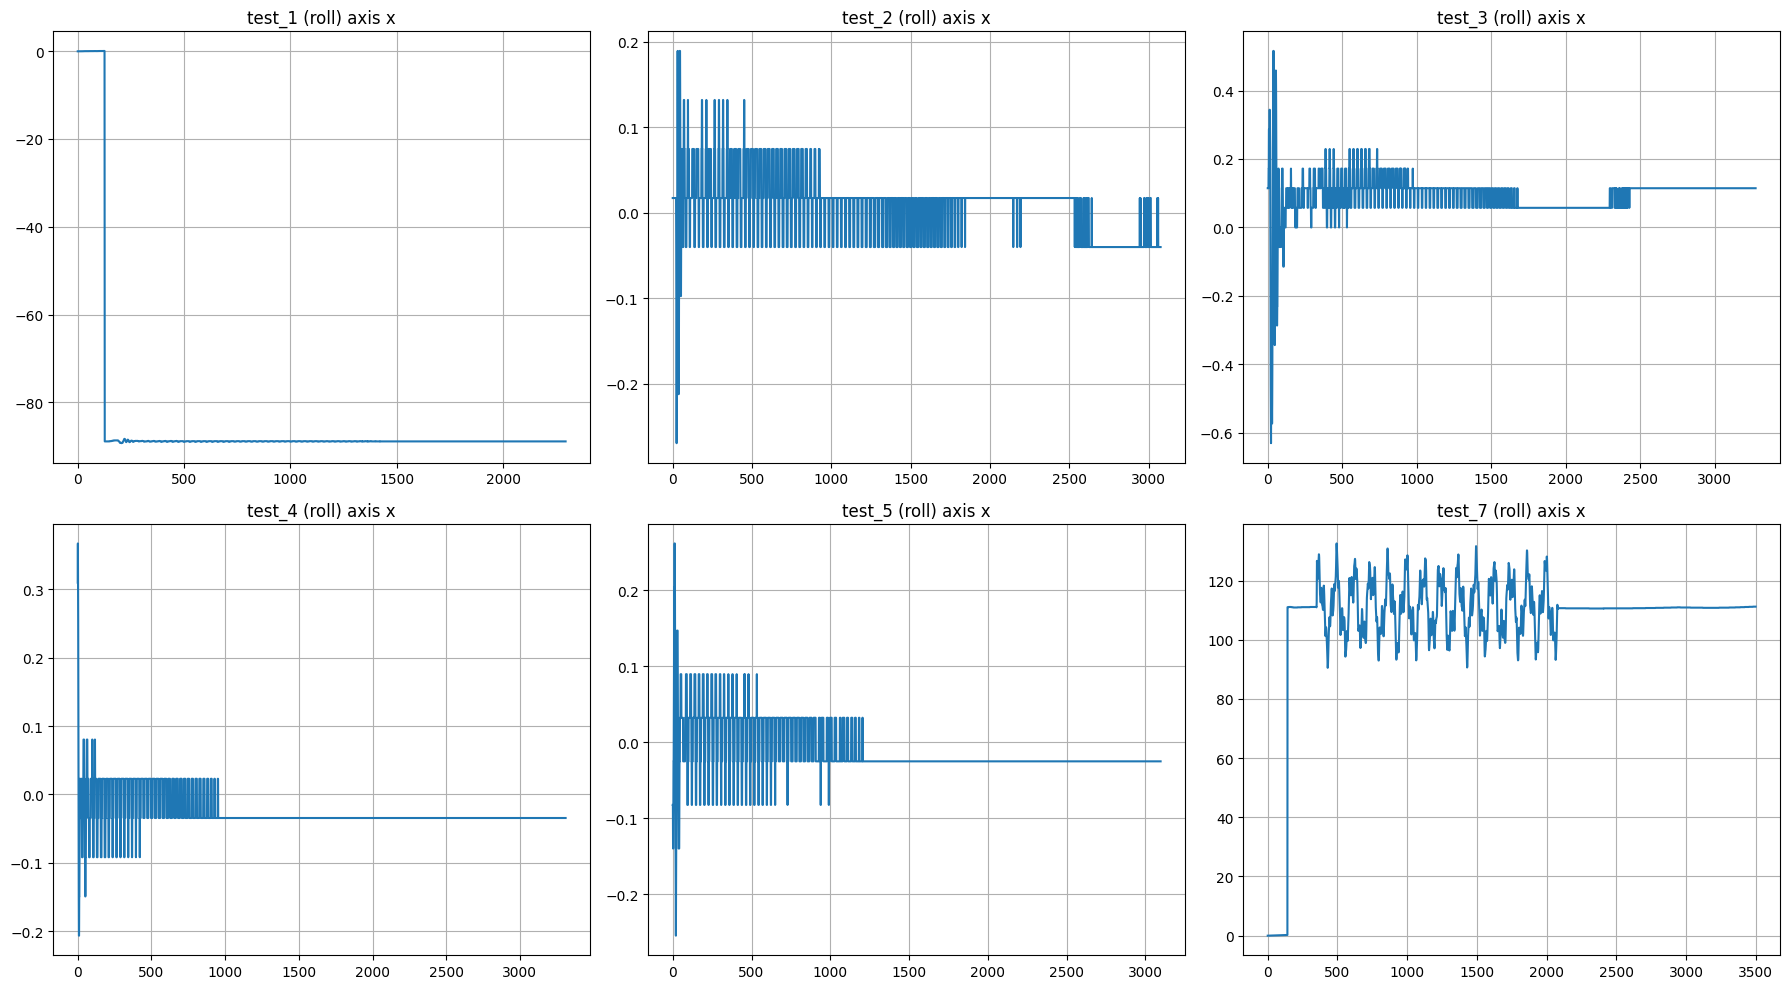

In [23]:
axis = 'x'
var  = 'roll'
graphs = {}

for id, data in tests.items():
    if data[axis] is None:
        continue

    values = data[axis][var].to_numpy()
    graphs[f'test_{id} ({var}) axis {axis}'] = values

compareAxis(graphs, normalize=True)

# COMPARANDO FREQUÊNCIAS - Kongsberg

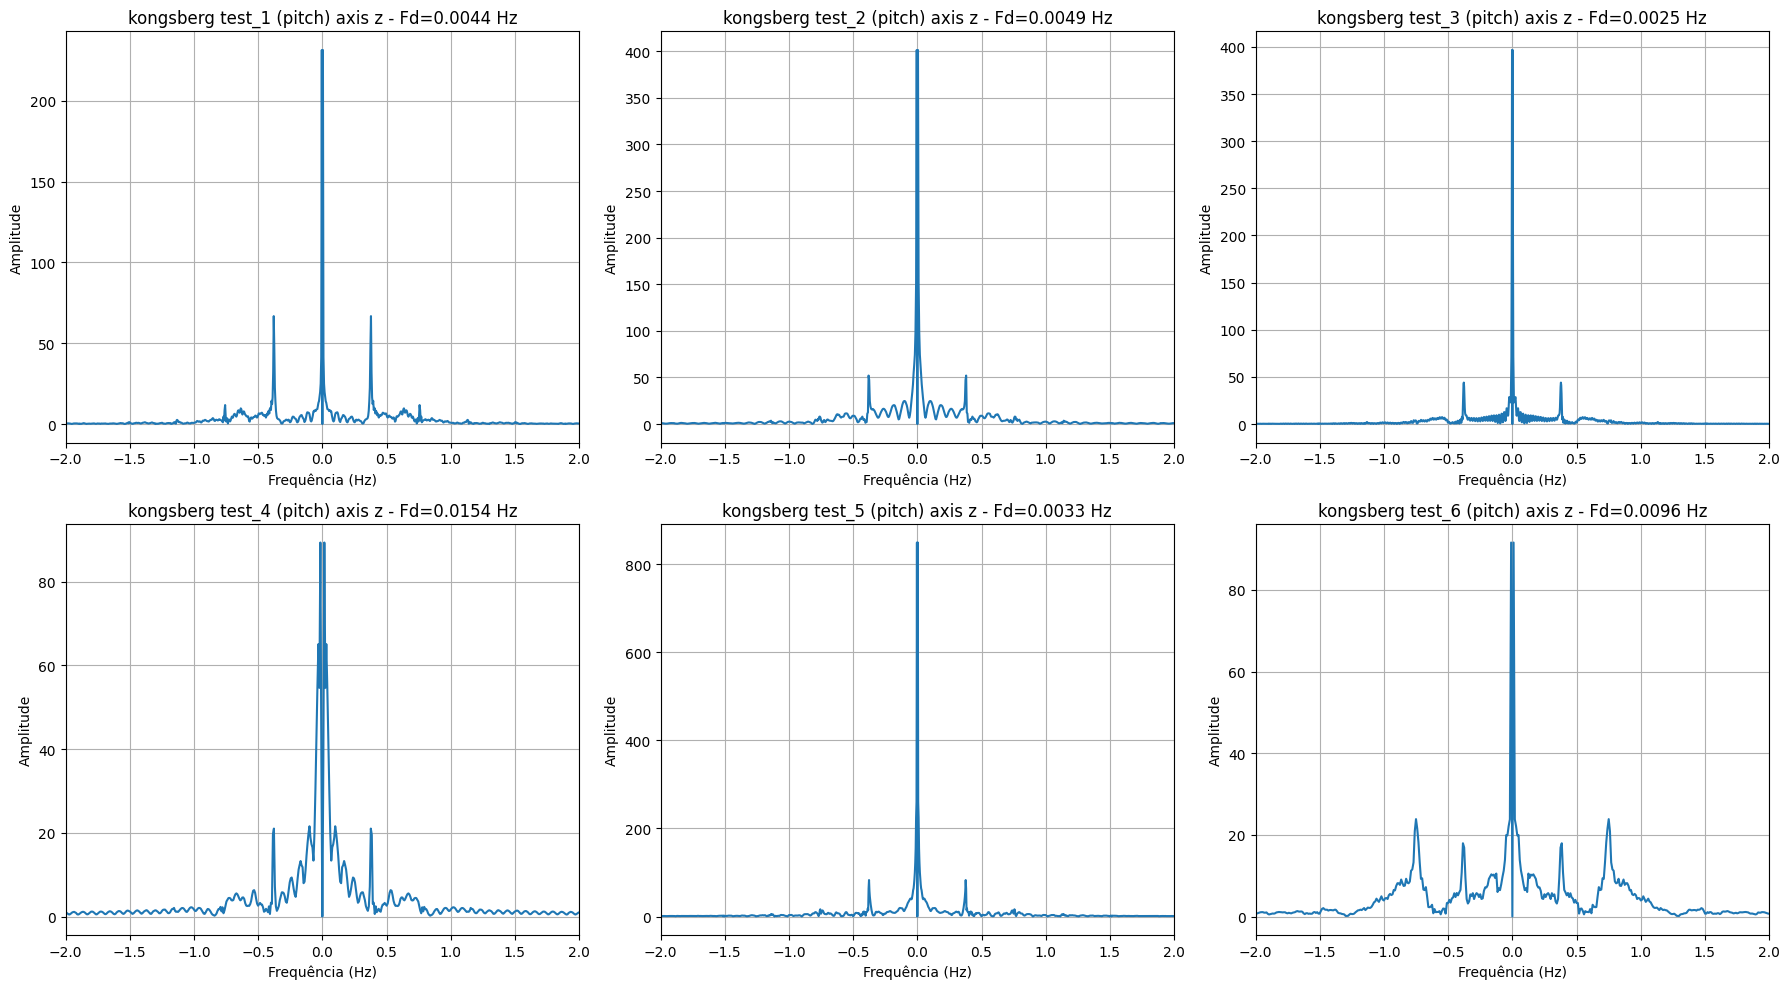

In [24]:
axis = 'z'
var  = 'pitch'
graphs = {}

for id, data in tests.items():
    if data[axis] is None:
        continue

    values = data[axis][var].to_numpy()
    graphs[f'kongsberg test_{id} ({var}) axis {axis}'] = values

compareFrequencies(graphs)